# CSCI 4022 Final Project

### A study on the correlation between basketball stats and how they sort players into archetypes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
#====================================================Load Data=============================================================================
stats = pd.read_csv("PlayerStatistics.csv", low_memory=False)
players = pd.read_csv("Players.csv")
#print(stats.columns)
#print(players.columns)
#=============================================Set the season dates for the 25-26 season ===================================================
stats["gameDate"] = pd.to_datetime(stats["gameDate"])
df = stats[
    (stats["gameDate"] >= "2025-10-21") &
    (stats["gameDate"] <= "2026-04-12")
].copy()
#Regular season only
df = df[df["gameType"] == "Regular Season"]
#===================================Convert columns into numeric so that we can average===================================================
numeric_cols = [
    "points",
    "reboundsOffensive",
    "reboundsDefensive",
    "assists",
    "steals",
    "blocks",
    "turnovers",
    "numMinutes",
    "fieldGoalsPercentage",
    "threePointersPercentage"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
#remove DNP
df = df[df["numMinutes"] > 0].copy()
#=============================================Average the stats =========================================================================
player_avg = df.groupby("personId").agg({
    "points": "mean",
    "reboundsOffensive": "mean",
    "reboundsDefensive": "mean",
    "assists": "mean",
    "steals": "mean",
    "blocks": "mean",
    "turnovers": "mean",
    "numMinutes": "mean",
    "fieldGoalsPercentage": "mean",
    "threePointersPercentage": "mean"
}).reset_index()

## Now that players' stats have been averaged for the season, we implement a minutes cutoff.

In [3]:
minute_cutoff = 10
player_avg = player_avg[
    player_avg["numMinutes"] >= minute_cutoff
]

## Here we merge the data we've accumulated to the players.csv data 

In [4]:
data = player_avg.merge(players, on="personId", how="left")

## Choose the clustering factors and clean data

In [5]:
features = [
    "points",
    "reboundsOffensive",
    "reboundsDefensive",
    "assists",
    "steals",
    "blocks",
    "turnovers",
    "numMinutes",
    "fieldGoalsPercentage",
    "threePointersPercentage"
]
X = data[features].fillna(0)

## Here, we scale the data because the stats are skewed. Point averages are higher than rebound averages, or assist averages, etc. Because it is a higher number, it effects the K-means more than the other statistics do. By scaling it, we remove that factor, so that each statistic can effect the cluster by the same weight.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Now we run the elbow method ot find the best k

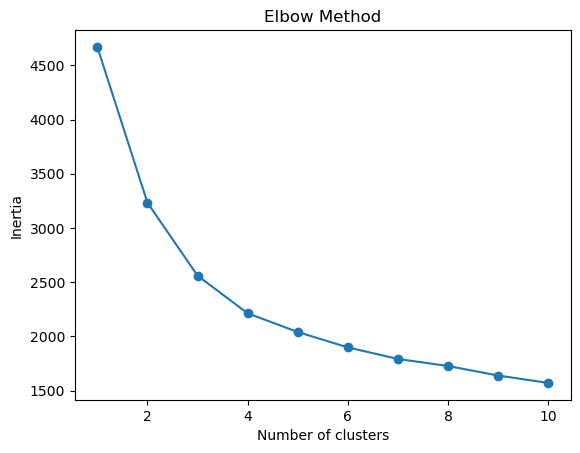

In [7]:
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(range(1, 11), inertias, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## From this graph, I have chosen a K of 4, as it is roughly where the "elbow" is.

## Now we run K means with K = 4

In [8]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_scaled)

In [16]:
cluster_summary = data.groupby("cluster")[features].mean()
cluster_summary.round(2)

,points,reboundsOffensive,reboundsDefensive,assists,steals,blocks,turnovers,numMinutes,fieldGoalsPercentage,threePointersPercentage
cluster,,,,,,,,,,
0,11.03,0.90,2.93,2.39,0.88,0.42,1.23,24.59,0.44,0.33
1,5.49,0.68,1.70,1.40,0.51,0.23,0.75,14.81,0.37,0.24
2,9.96,2.68,4.70,1.72,0.73,1.04,1.27,22.74,0.58,0.09
3,20.35,1.11,4.55,5.36,1.19,0.49,2.54,31.53,0.47,0.33


## Now, we compare the players in each cluster to thier assigned position for later

In [10]:
def get_position(row):
    if row["guard"] == 1:
        return "Guard"
    if row["forward"] == 1:
        return "Forward"
    if row["center"] == 1:
        return "Center"
    return "Unknown"
data["position"] = data.apply(get_position, axis=1)
pd.crosstab(data["cluster"], data["position"])

position,Center,Forward,Guard
cluster,,,
0,6,70,107
1,9,54,83
2,32,26,1
3,3,25,51


## Now we do a simple PCA visualization to show the different cliusters

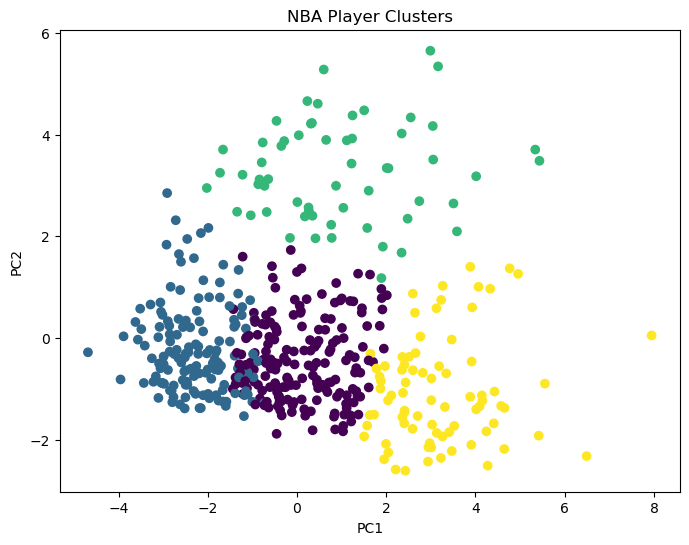

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
data["PC1"] = X_pca[:,0]
data["PC2"] = X_pca[:,1]
plt.figure(figsize=(8,6))
plt.scatter(
    data["PC1"],
    data["PC2"],
    c=data["cluster"]
)
plt.title("NBA Player Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## We now have out clusters and can make conclusions on that, but now we user the clusters to find the players that are "Out of Position"

In [12]:
cluster_position_table = pd.crosstab(
    data["cluster"],
    data["position"]
)
expected_position = cluster_position_table.idxmax(axis=1)

data["expected_position"] = data["cluster"].map(expected_position)
out_of_position_players = data[
    data["position"] != data["expected_position"]
].copy()
# Columns you want to see
cols_to_show = [
    "firstName",
    "lastName",
    "points",
    "reboundsOffensive",
    "reboundsDefensive",
    "assists",
    "steals",
    "blocks",
    "turnovers",
    "numMinutes",
    "fieldGoalsPercentage",
    "threePointersPercentage",
    "cluster",
    "PC1",
    "PC2",
    "position",
    "expected_position"
]
# Show total number of out-of-position players
print("Total out-of-position players:", len(out_of_position_players))
# Display the table
out_of_position_players[cols_to_show].sort_values(
    by=["cluster", "points"],
    ascending=[True, False]
).round(2)

Total out-of-position players: 194


,firstName,lastName,points,reboundsOffensive,reboundsDefensive,assists,steals,blocks,turnovers,numMinutes,fieldGoalsPercentage,threePointersPercentage,cluster,PC1,PC2,position,expected_position
39,Jerami,Grant,18.60,0.96,2.51,2.14,0.74,0.63,2.09,29.54,0.45,0.37,0,1.30,-0.68,Forward,Guard
111,Miles,Bridges,17.20,0.99,4.92,3.21,0.61,0.45,1.41,30.89,0.46,0.30,0,1.48,-0.18,Forward,Guard
52,Kristaps,Porzingis,16.81,1.23,3.90,2.58,0.58,1.23,1.32,23.82,0.43,0.31,0,0.97,0.74,Forward,Guard
369,Matas,Buzelis,16.26,1.00,4.82,2.05,0.71,1.51,2.06,28.98,0.46,0.34,0,2.01,0.84,Forward,Guard
41,Aaron,Gordon,16.17,1.42,4.39,2.67,0.58,0.28,1.06,27.70,0.45,0.34,0,0.80,-0.10,Forward,Guard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,Paul,George,17.50,0.56,4.75,3.64,1.72,0.44,1.75,30.80,0.42,0.37,3,2.41,-1.43,Forward,Guard
186,Onyeka,Okongwu,15.18,1.89,5.70,3.12,1.11,1.07,1.72,30.82,0.48,0.34,3,2.60,0.87,Forward,Guard
390,Kyshawn,George,14.79,0.90,4.21,4.46,1.00,0.90,2.60,28.79,0.44,0.35,3,2.35,-0.63,Forward,Guard
50,Jusuf,Nurkic,10.90,2.59,7.78,4.78,1.27,0.54,2.46,26.22,0.51,0.31,3,3.27,1.02,Center,Guard


In [13]:
print("Pecent of players playing out of position:", (len(out_of_position_players) / df["personId"].nunique()))
df["personId"].nunique()

Pecent of players playing out of position: 0.33448275862068966


580

# Conclusions

From the out of position players, we mostly see role-player / bench players. This makes the most sense, as these would be the people teams would need to step it up outside of their given role.

As for the clusters and the archetypes, we can see that there are distinctions.
  
Cluster 0: 3 and D wing. Contribute moderately to scoring. shoot good from 3. Generate steals. Plays a generous amount of minutes.

Cluster 1: Low usage rotational guard. Play low minutes, contribute less to stats, have the ball less often, score less. Primarilry second unit roles.

Cluster 2: Interior Anchor. Rebound the most, block the most, shoot best near the basket and rarely shoots threes. Low playmkaing responsibilities.
    
Cluster 3: Primary Shot Creator. Score and assist the most. Handle the ball the most, play the most minutes. Initiators of the offense.